# Week 11 — Thursday (Jun 18, Remote): Custom Training

## Learning Objectives
- Understand YOLO annotation format and dataset directory structure
- Build an Albumentations augmentation pipeline for object detection
- Implement Mosaic augmentation from scratch
- Cluster anchor sizes with k-Means on ground-truth boxes
- Configure `data.yaml` and understand the YOLOv8 training pipeline
- Generate and visualise a synthetic 200-image labelled dataset

## Key Concepts
1. **YOLO format** — `class_id cx cy w h` (all normalised 0-1 relative to image)
2. **Dataset structure** — `images/train/`, `labels/train/`, `data.yaml`
3. **Albumentations** — detection-aware transforms with `bbox_params`
4. **Mosaic augmentation** — 4 images combined into 2x2 grid (YOLOv4+ key trick)
5. **Anchor clustering** — k-Means on (w, h) pairs to find optimal anchor sizes
6. **Training pipeline** — annotate → augment → train → evaluate → export

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle
import cv2
import os
import warnings
warnings.filterwarnings('ignore')

try:
    import albumentations as A
    HAS_ALBUM = True
    print(f'albumentations {A.__version__} available')
except ImportError:
    HAS_ALBUM = False
    print('albumentations not found — install: pip install albumentations')

plt.rcParams['figure.figsize'] = (14, 8)
np.random.seed(42)
print('Setup complete')

albumentations 2.0.8 available
Setup complete


## Section 1: YOLO Annotation Format

Every YOLO label file (`.txt`) has one line per object:
```
class_id  cx  cy  w  h
```
- All values **normalised 0-1** (divide by image width/height)
- `(cx, cy)` — bounding-box centre
- `(w, h)` — bounding-box size
- No confidence score in labels — only in predictions

**Example** (640x480 image, dog at pixel x1=100, y1=120, w=200, h=150):
```
16  0.3125  0.3125  0.3125  0.3125
#   cx=300/640  cy=195/480  w=200/640  h=150/480
```

### LabelImg Workflow
```bash
pip install labelImg
labelImg              # open GUI
# 1. Open image directory
# 2. Set save format to YOLO
# 3. Draw bounding boxes + assign class
# 4. Save — creates .txt file per image automatically
```

YOLO annotation file content:
  0 0.312500 0.406250 0.312500 0.312500  <- dog
  2 0.617188 0.281250 0.140625 0.229167  <- bird
  4 0.390625 0.718750 0.093750 0.270833  <- person

Round-trip check (YOLO -> absolute):
  dog     : round-trip error = 0.000000
  bird    : round-trip error = 0.000560
  person  : round-trip error = 0.000240


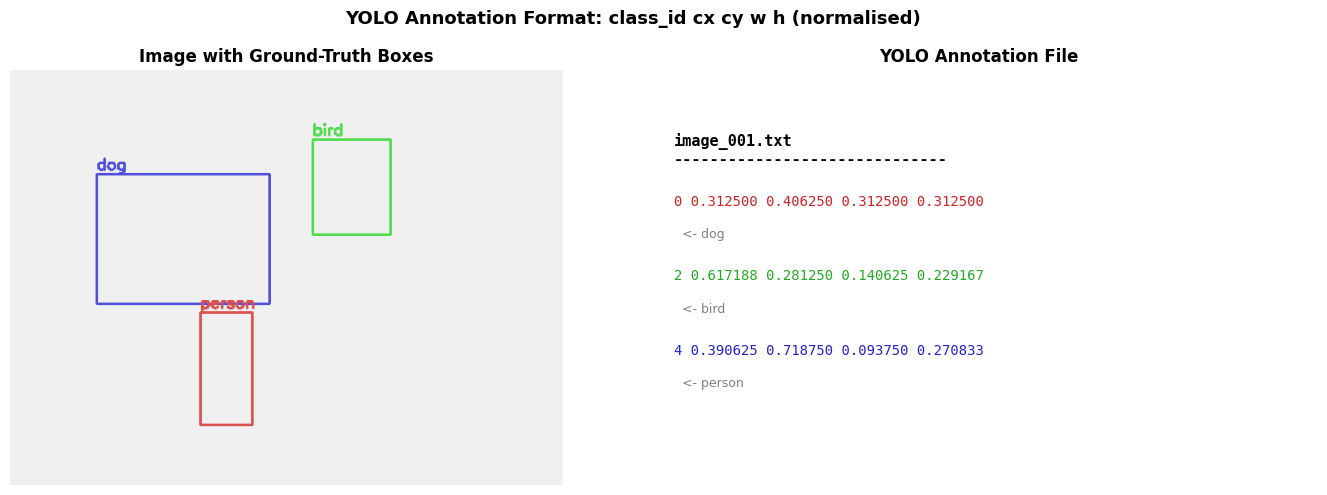

Saved yolo_format.png


In [2]:
# ── YOLO format utilities ─────────────────────────────────────────────────────

def to_yolo(class_id, x1, y1, bw, bh, img_w, img_h):
    """Convert absolute xyxy + wh to YOLO normalised format."""
    cx = (x1 + bw / 2) / img_w
    cy = (y1 + bh / 2) / img_h
    nw = bw / img_w
    nh = bh / img_h
    return f"{class_id} {cx:.6f} {cy:.6f} {nw:.6f} {nh:.6f}"

def from_yolo(line, img_w, img_h):
    """Parse a YOLO annotation line to absolute x1,y1,w,h."""
    parts = line.strip().split()
    cls   = int(parts[0])
    cx, cy, nw, nh = float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
    bw = nw * img_w;  bh = nh * img_h
    x1 = cx * img_w - bw / 2
    y1 = cy * img_h - bh / 2
    return cls, x1, y1, bw, bh

# ── Demo ──────────────────────────────────────────────────────────────────────
IMG_W, IMG_H = 640, 480
CLASS_NAMES  = ['dog', 'cat', 'bird', 'car', 'person']

sample_boxes = [
    (0, 100, 120, 200, 150),   # dog
    (2, 350, 80,  90,  110),   # bird
    (4, 220, 280, 60,  130),   # person
]

print('YOLO annotation file content:')
print('=' * 50)
yolo_lines = []
for cls_id, x1, y1, bw, bh in sample_boxes:
    line = to_yolo(cls_id, x1, y1, bw, bh, IMG_W, IMG_H)
    yolo_lines.append(line)
    print(f'  {line}  <- {CLASS_NAMES[cls_id]}')

print()
print('Round-trip check (YOLO -> absolute):')
for line, (cls_id, x1, y1, bw, bh) in zip(yolo_lines, sample_boxes):
    cls_back, x1b, y1b, bwb, bhb = from_yolo(line, IMG_W, IMG_H)
    err = abs(x1 - x1b) + abs(y1 - y1b) + abs(bw - bwb) + abs(bh - bhb)
    print(f'  {CLASS_NAMES[cls_id]:8s}: round-trip error = {err:.6f}')

# ── Visualise ─────────────────────────────────────────────────────────────────
canvas = np.ones((IMG_H, IMG_W, 3), dtype=np.uint8) * 240
colors = [(220, 80, 80), (80, 220, 80), (80, 80, 220)]
for i, (cls_id, x1, y1, bw, bh) in enumerate(sample_boxes):
    c = colors[i]
    cv2.rectangle(canvas, (int(x1), int(y1)),
                  (int(x1+bw), int(y1+bh)), c, 2)
    cv2.putText(canvas, CLASS_NAMES[cls_id],
                (int(x1), max(int(y1)-5, 15)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, c, 2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB))
axes[0].set_title('Image with Ground-Truth Boxes', fontweight='bold')
axes[0].axis('off')

# Show YOLO file as text
axes[1].text(0.05, 0.85, 'image_001.txt\n' + '-'*30, transform=axes[1].transAxes,
             fontfamily='monospace', fontsize=11, va='top', fontweight='bold')
for i, line in enumerate(yolo_lines):
    col = ['#cc2222', '#22aa22', '#2222cc'][i]
    axes[1].text(0.05, 0.70 - i*0.18, line, transform=axes[1].transAxes,
                 fontfamily='monospace', fontsize=10, va='top', color=col)
    axes[1].text(0.05, 0.62 - i*0.18, f'  <- {CLASS_NAMES[sample_boxes[i][0]]}',
                 transform=axes[1].transAxes, fontsize=9, va='top', color='grey')
axes[1].set_xlim(0, 1); axes[1].set_ylim(0, 1)
axes[1].axis('off')
axes[1].set_title('YOLO Annotation File', fontweight='bold')
plt.suptitle('YOLO Annotation Format: class_id cx cy w h (normalised)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('yolo_format.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved yolo_format.png')

## Section 2: Dataset Structure & Synthetic Dataset

YOLOv8 expects this exact directory layout:
```
dataset/
  images/
    train/   ← training images (.jpg / .png)
    val/     ← validation images
  labels/
    train/   ← YOLO .txt files (same name as images)
    val/
  data.yaml  ← dataset config
```

**data.yaml** tells YOLOv8 where to look and what classes exist:
```yaml
path: /path/to/dataset
train: images/train
val:   images/val

nc: 5          # number of classes
names: ['dog', 'cat', 'bird', 'car', 'person']
```

Synthetic dataset created:
  Train images : 160
  Val   images : 40
  Classes      : ['circle', 'rectangle', 'triangle', 'star', 'ellipse']
  data.yaml    :
path: ./synthetic_dataset
train: images/train
val:   images/val

nc: 5
names: ['circle', 'rectangle', 'triangle', 'star', 'ellipse']



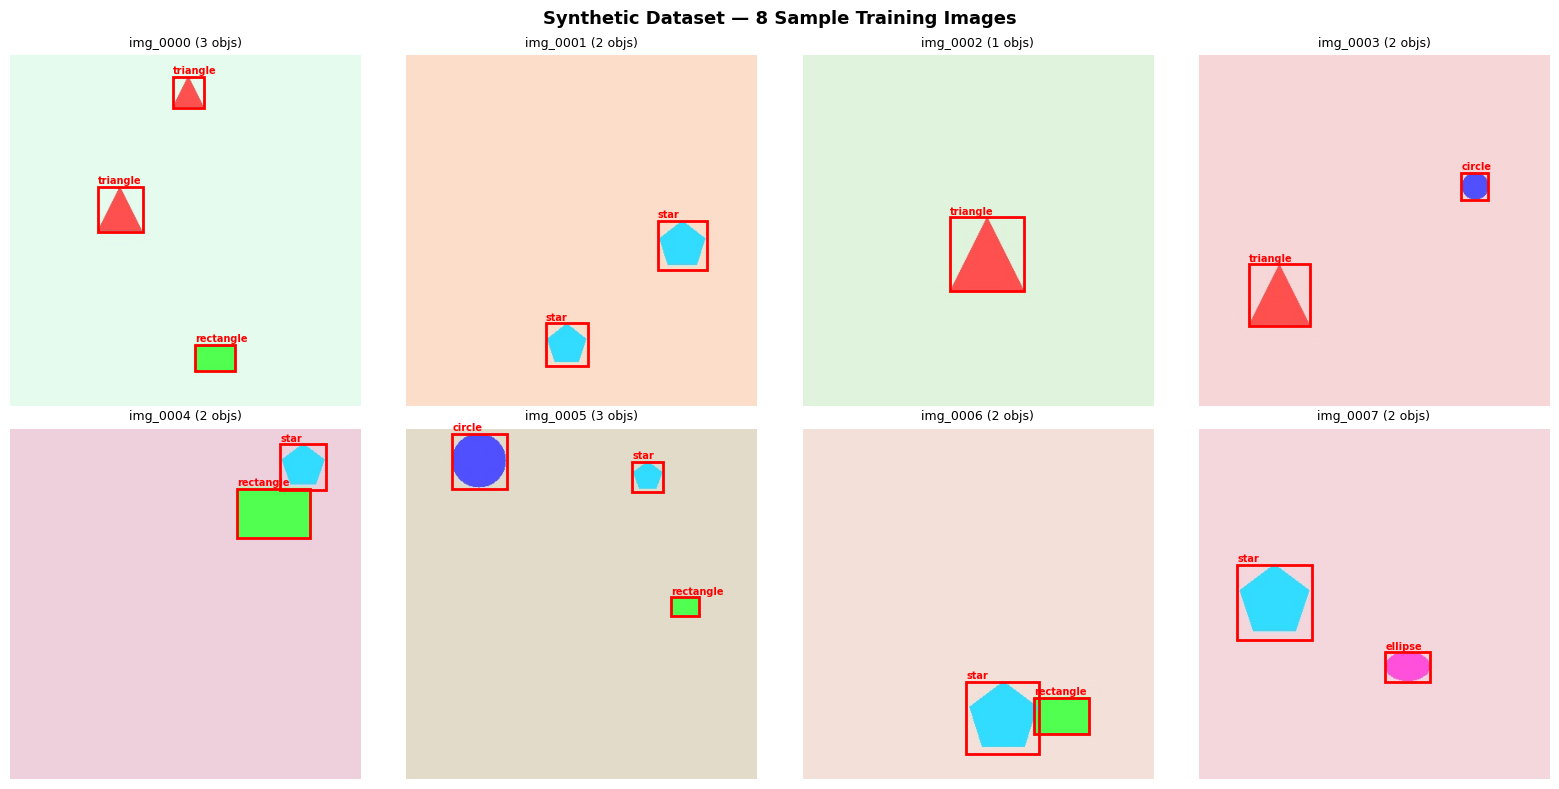

Saved dataset_samples.png


In [3]:
# ── Generate a synthetic 200-image dataset ────────────────────────────────────

SYNTH_DIR  = 'synthetic_dataset'
IMG_W, IMG_H = 416, 416
N_TRAIN, N_VAL = 160, 40
CLASS_NAMES = ['circle', 'rectangle', 'triangle', 'star', 'ellipse']
N_CLASSES   = len(CLASS_NAMES)
COLORS_BGR  = [(255,80,80), (80,255,80), (80,80,255), (255,220,50), (220,80,255)]

def draw_shape(canvas, class_id, cx, cy, size):
    """Draw a synthetic 'object' and return the bounding box."""
    col = COLORS_BGR[class_id]
    if class_id == 0:   # circle
        cv2.circle(canvas, (cx, cy), size//2, col, -1)
        x1, y1, bw, bh = cx-size//2, cy-size//2, size, size
    elif class_id == 1: # rectangle
        x1, y1 = cx-size//2, cy-size//3
        bw, bh = size, size*2//3
        cv2.rectangle(canvas, (x1, y1), (x1+bw, y1+bh), col, -1)
    elif class_id == 2: # triangle
        pts = np.array([[cx, cy-size//2],
                        [cx-size//2, cy+size//2],
                        [cx+size//2, cy+size//2]], np.int32)
        cv2.fillPoly(canvas, [pts], col)
        x1, y1, bw, bh = cx-size//2, cy-size//2, size, size
    elif class_id == 3: # star (drawn as pentagon)
        angles = np.linspace(0, 2*np.pi, 6)[:-1] - np.pi/2
        pts = np.array([[cx + int(size//2*np.cos(a)), cy + int(size//2*np.sin(a))] for a in angles], np.int32)
        cv2.fillPoly(canvas, [pts], col)
        x1, y1, bw, bh = cx-size//2, cy-size//2, size, size
    else:               # ellipse
        cv2.ellipse(canvas, (cx, cy), (size//2, size//3), 0, 0, 360, col, -1)
        x1, y1, bw, bh = cx-size//2, cy-size//3, size, size*2//3
    return x1, y1, bw, bh

def generate_image(idx):
    """Generate one synthetic image with 1-4 objects."""
    bg_col = np.random.randint(200, 255, 3).tolist()
    canvas = np.full((IMG_H, IMG_W, 3), bg_col, dtype=np.uint8)
    n_obj  = np.random.randint(1, 5)
    labels = []
    for _ in range(n_obj):
        cls_id = np.random.randint(0, N_CLASSES)
        size   = np.random.randint(30, 90)
        margin = size // 2 + 5
        cx     = np.random.randint(margin, IMG_W - margin)
        cy     = np.random.randint(margin, IMG_H - margin)
        x1, y1, bw, bh = draw_shape(canvas, cls_id, cx, cy, size)
        x1 = max(0, x1); y1 = max(0, y1)
        bw = min(bw, IMG_W - x1); bh = min(bh, IMG_H - y1)
        if bw > 5 and bh > 5:
            lbl = to_yolo(cls_id, x1, y1, bw, bh, IMG_W, IMG_H)
            labels.append(lbl)
    return canvas, labels

# Create directories
for split in ['train', 'val']:
    os.makedirs(f'{SYNTH_DIR}/images/{split}', exist_ok=True)
    os.makedirs(f'{SYNTH_DIR}/labels/{split}',  exist_ok=True)

# Generate images
counts = {'train': N_TRAIN, 'val': N_VAL}
for split, n in counts.items():
    for i in range(n):
        img, lbls = generate_image(i)
        img_path = f'{SYNTH_DIR}/images/{split}/{i:04d}.jpg'
        lbl_path = f'{SYNTH_DIR}/labels/{split}/{i:04d}.txt'
        cv2.imwrite(img_path, img)
        with open(lbl_path, 'w') as f:
            f.write('\n'.join(lbls))

# Write data.yaml
yaml_content = f"""path: ./{SYNTH_DIR}
train: images/train
val:   images/val

nc: {N_CLASSES}
names: {CLASS_NAMES}
"""
with open(f'{SYNTH_DIR}/data.yaml', 'w') as f:
    f.write(yaml_content)

print(f'Synthetic dataset created:')
print(f'  Train images : {N_TRAIN}')
print(f'  Val   images : {N_VAL}')
print(f'  Classes      : {CLASS_NAMES}')
print(f'  data.yaml    :')
print(yaml_content)

# ── Visualise sample images ───────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax_i, ax in enumerate(axes.flat):
    img = cv2.imread(f'{SYNTH_DIR}/images/train/{ax_i:04d}.jpg')
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    with open(f'{SYNTH_DIR}/labels/train/{ax_i:04d}.txt') as f:
        lines = f.read().strip().split('\n')
    for line in lines:
        if line.strip():
            cls_id, x1, y1, bw, bh = from_yolo(line, IMG_W, IMG_H)
            rect = Rectangle((x1, y1), bw, bh, linewidth=2,
                              edgecolor='red', facecolor='none')
            ax.add_patch(rect)
            ax.text(x1, y1-3, CLASS_NAMES[cls_id], color='red', fontsize=7, fontweight='bold')
    ax.imshow(img_rgb)
    ax.set_title(f'img_{ax_i:04d} ({len([l for l in lines if l])} objs)', fontsize=9)
    ax.axis('off')
plt.suptitle('Synthetic Dataset — 8 Sample Training Images', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('dataset_samples.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved dataset_samples.png')

## Section 3: Albumentations — Detection-Aware Augmentation

Standard augmentation libraries transform **images only**.
Albumentations transforms **both the image and its bounding boxes simultaneously**
using `bbox_params`.

### Key Albumentations Transforms for Detection

| Transform | What it does | Impact on boxes |
|-----------|-------------|----------------|
| `HorizontalFlip` | Mirror image left-right | `cx -> 1 - cx` |
| `RandomBrightnessContrast` | Vary brightness/contrast | No box change |
| `HueSaturationValue` | Colour jitter | No box change |
| `ShiftScaleRotate` | Translate + scale + rotate | Boxes transformed |
| `RandomCrop` | Crop a region | Boxes clipped/removed |
| `Blur` | Add blur | No box change |
| `GaussNoise` | Add Gaussian noise | No box change |
| `RandomShadow` | Add shadow region | No box change |

### bbox_params format
```python
A.Compose(
    transforms=[...],
    bbox_params=A.BboxParams(
        format='yolo',          # or 'pascal_voc', 'coco', 'albumentations'
        label_fields=['class_labels'],
        min_visibility=0.2,     # drop boxes where <20% visible after crop
    )
)
```

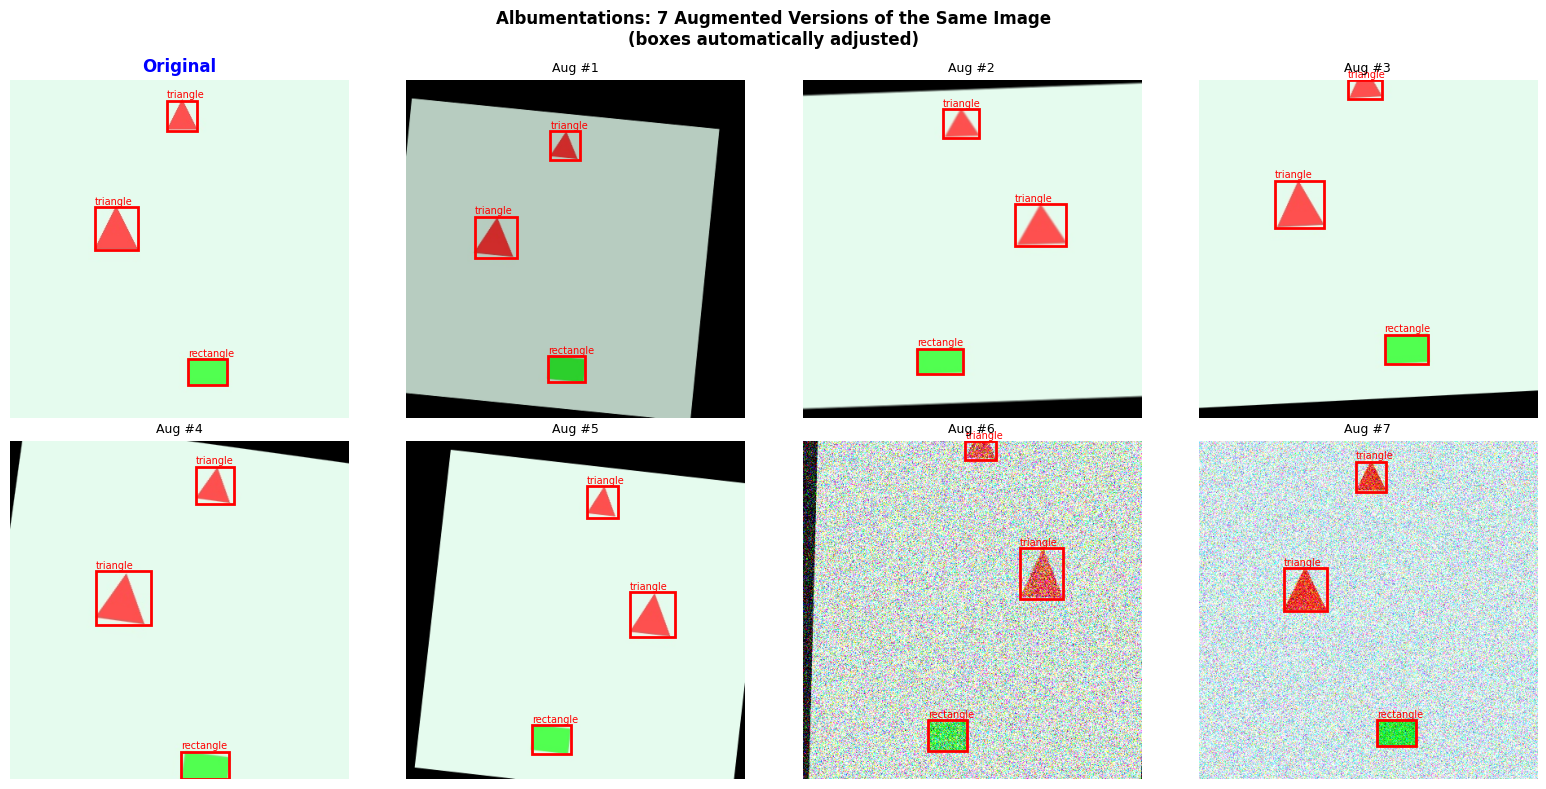

Saved albumentations_demo.png
Albumentations pipeline: ['HorizontalFlip', 'RandomBrightnessContrast', 'HueSaturationValue', 'ShiftScaleRotate', 'Blur', 'GaussNoise']


In [4]:
if not HAS_ALBUM:
    print('albumentations not available — showing manual augmentation fallback')
else:
    # ── Define augmentation pipeline ──────────────────────────────────────────
    train_transform = A.Compose([
        A.HorizontalFlip(p=0.5),
        A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.7),
        A.HueSaturationValue(hue_shift_limit=15, sat_shift_limit=30, val_shift_limit=20, p=0.5),
        A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.15, rotate_limit=10, p=0.6,
                           border_mode=cv2.BORDER_CONSTANT),
        A.Blur(blur_limit=3, p=0.2),
        A.GaussNoise(p=0.2),
    ], bbox_params=A.BboxParams(
        format='yolo',
        label_fields=['class_labels'],
        min_visibility=0.2,
        clip=True
    ))

    # Load one sample image + labels
    sample_img  = cv2.imread(f'{SYNTH_DIR}/images/train/0000.jpg')
    sample_img  = cv2.cvtColor(sample_img, cv2.COLOR_BGR2RGB)
    with open(f'{SYNTH_DIR}/labels/train/0000.txt') as f:
        raw_lines = [l.strip() for l in f.readlines() if l.strip()]

    bboxes, cls_ids = [], []
    for line in raw_lines:
        parts = line.split()
        cls_ids.append(int(parts[0]))
        bboxes.append([float(p) for p in parts[1:]])

    # Apply augmentation 7 times
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes_flat = axes.flat

    def draw_yolo_boxes(ax, img, bboxes, cls_ids):
        ax.imshow(img)
        h, w = img.shape[:2]
        for (cx, cy, bw, bh), cls_id in zip(bboxes, cls_ids):
            x1 = (cx - bw/2) * w;  y1 = (cy - bh/2) * h
            rect = Rectangle((x1, y1), bw*w, bh*h,
                              linewidth=2, edgecolor='red', facecolor='none')
            ax.add_patch(rect)
            ax.text(x1, y1-3, CLASS_NAMES[int(cls_id)], color='red', fontsize=7)
        ax.axis('off')

    ax0 = next(axes_flat)
    draw_yolo_boxes(ax0, sample_img, bboxes, cls_ids)
    ax0.set_title('Original', fontweight='bold', color='blue')

    for i in range(7):
        augmented = train_transform(image=sample_img, bboxes=bboxes, class_labels=cls_ids)
        ax = next(axes_flat)
        draw_yolo_boxes(ax, augmented['image'], augmented['bboxes'], augmented['class_labels'])
        ax.set_title(f'Aug #{i+1}', fontsize=9)

    plt.suptitle('Albumentations: 7 Augmented Versions of the Same Image\n'
                 '(boxes automatically adjusted)', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('albumentations_demo.png', dpi=100, bbox_inches='tight')
    plt.show()
    print('Saved albumentations_demo.png')
    print(f'Albumentations pipeline: {[t.__class__.__name__ for t in train_transform.transforms]}')

## Section 4: Mosaic Augmentation (from Scratch)

Introduced in **YOLOv4**, Mosaic is the most impactful single augmentation for detection:

### What it does
1. Pick 4 random training images
2. Choose a random centre point `(cx, cy)` in the output canvas
3. Resize each image to fit its quadrant (TL, TR, BL, BR)
4. Adjust bounding-box coordinates to match the new layout
5. Train on the combined 1x image containing 4x the object density

### Why it works
- Forces the model to see objects in unusual contexts and at smaller scales
- Provides 4x as many objects per forward pass
- Reduces BatchNorm's need for large batches (each mosaic approximates a batch of 4)
- Especially helps with **small object detection**

```
+──────────+──────────+
|          |          |
|  img_0   |  img_1   |  TL quadrant / TR quadrant
|  (cx,cy)─┼──────────|
+──────────+──────────+
|          |          |
|  img_2   |  img_3   |  BL quadrant / BR quadrant
|          |          |
+──────────+──────────+
```

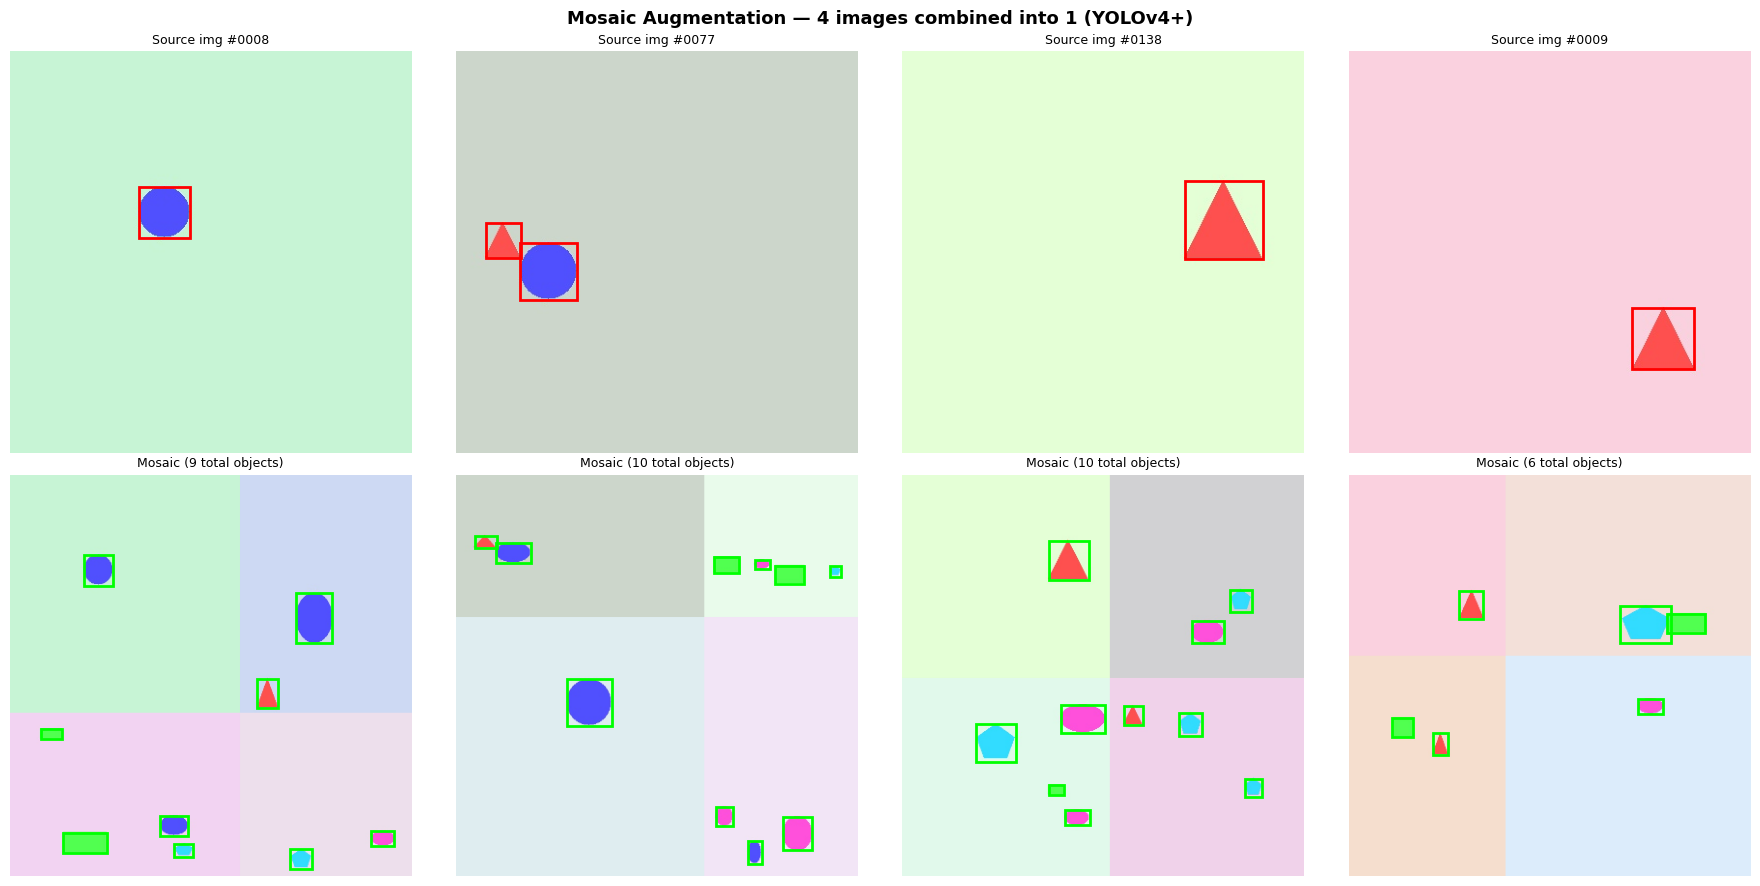

Saved mosaic_augmentation.png


In [5]:
def load_sample(idx, split='train'):
    """Load image + labels from synthetic dataset."""
    img = cv2.cvtColor(
        cv2.imread(f'{SYNTH_DIR}/images/{split}/{idx:04d}.jpg'),
        cv2.COLOR_BGR2RGB
    )
    with open(f'{SYNTH_DIR}/labels/{split}/{idx:04d}.txt') as f:
        lines = [l.strip() for l in f if l.strip()]
    labels = []
    for line in lines:
        parts = line.split()
        labels.append([int(parts[0])] + [float(p) for p in parts[1:]])
    return img, np.array(labels) if labels else np.zeros((0, 5))


def mosaic_augment(imgs, labels_list, target_size=416):
    """Combine 4 images into a 2x2 mosaic with adjusted annotations."""
    assert len(imgs) == 4
    H = W = target_size
    # Random centre within 35-65% of canvas to avoid degenerate slices
    cx = int(W * np.random.uniform(0.35, 0.65))
    cy = int(H * np.random.uniform(0.35, 0.65))

    mosaic       = np.full((H, W, 3), 128, dtype=np.uint8)
    mosaic_lbls  = []

    # Each quadrant: (dst_x1, dst_y1, dst_x2, dst_y2)
    quads = [
        (0,  0,  cx, cy),     # top-left
        (cx, 0,  W,  cy),     # top-right
        (0,  cy, cx, H ),     # bottom-left
        (cx, cy, W,  H ),     # bottom-right
    ]

    for img, lbls, (qx1, qy1, qx2, qy2) in zip(imgs, labels_list, quads):
        qw, qh = qx2 - qx1, qy2 - qy1
        img_r  = cv2.resize(img, (qw, qh))
        mosaic[qy1:qy2, qx1:qx2] = img_r

        for lbl in lbls:
            cls_id          = int(lbl[0])
            # Box centre in mosaic pixel coords
            abs_cx = lbl[1] * qw + qx1
            abs_cy = lbl[2] * qh + qy1
            abs_w  = lbl[3] * qw
            abs_h  = lbl[4] * qh
            # Clip to mosaic bounds
            abs_cx = np.clip(abs_cx, qx1, qx2)
            abs_cy = np.clip(abs_cy, qy1, qy2)
            abs_w  = min(abs_w, qw)
            abs_h  = min(abs_h, qh)
            # Normalise to mosaic size
            ncx, ncy = abs_cx / W, abs_cy / H
            nw,  nh  = abs_w  / W, abs_h  / H
            if nw > 0.01 and nh > 0.01:
                mosaic_lbls.append([cls_id, ncx, ncy, nw, nh])

    lbls_arr = np.array(mosaic_lbls) if mosaic_lbls else np.zeros((0, 5))
    return mosaic, lbls_arr


# ── Visualise 4 mosaics ───────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 9))

for col in range(4):
    indices = np.random.choice(N_TRAIN, 4, replace=False)
    imgs4   = [load_sample(i)[0] for i in indices]
    lbls4   = [load_sample(i)[1] for i in indices]

    # Show one source image in row 0
    axes[0, col].imshow(imgs4[0])
    src_lbls = lbls4[0]
    for lbl in src_lbls:
        cls_id, ncx, ncy, nw, nh = int(lbl[0]), lbl[1], lbl[2], lbl[3], lbl[4]
        x1 = (ncx - nw/2) * IMG_W;  y1 = (ncy - nh/2) * IMG_H
        rect = Rectangle((x1, y1), nw*IMG_W, nh*IMG_H, lw=2, ec='red', fc='none')
        axes[0, col].add_patch(rect)
    axes[0, col].set_title(f'Source img #{indices[0]:04d}', fontsize=9)
    axes[0, col].axis('off')

    # Show mosaic in row 1
    mosaic, m_lbls = mosaic_augment(imgs4, lbls4)
    axes[1, col].imshow(mosaic)
    for lbl in m_lbls:
        cls_id, ncx, ncy, nw, nh = int(lbl[0]), lbl[1], lbl[2], lbl[3], lbl[4]
        x1 = (ncx - nw/2) * IMG_W;  y1 = (ncy - nh/2) * IMG_H
        rect = Rectangle((x1, y1), nw*IMG_W, nh*IMG_H, lw=2, ec='lime', fc='none')
        axes[1, col].add_patch(rect)
    axes[1, col].set_title(f'Mosaic ({len(m_lbls)} total objects)', fontsize=9)
    axes[1, col].axis('off')

axes[0, 0].set_ylabel('Source Image', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Mosaic (4 imgs)', fontsize=11, fontweight='bold')
plt.suptitle('Mosaic Augmentation — 4 images combined into 1 (YOLOv4+)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('mosaic_augmentation.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved mosaic_augmentation.png')

## Section 5: Anchor Clustering with k-Means

YOLOv2+ introduced anchor boxes — pre-defined aspect ratios that make regression easier.
The key insight: **anchors should match the actual distribution of your dataset's bounding boxes**.

**Standard approach:** run k-Means on `(w, h)` pairs from all ground-truth boxes.
Use **IoU distance** instead of Euclidean distance so cluster assignment is scale-invariant:

$$d(\text{box}, \text{centroid}) = 1 - \text{IoU}(\text{box}, \text{centroid})$$

YOLOv5/v8 uses k=9 anchors across 3 scales (3 per scale).
**YOLOv8 is anchor-free** — this section shows why anchors were used and how they were designed.

Total ground-truth boxes: 380
Width  range: 0.072 - 0.214
Height range: 0.048 - 0.214

Clustered 9 anchors (w x h, normalised):
  Anchor 1 (small ): w=0.082  h=0.062  ratio=1.31
  Anchor 2 (small ): w=0.091  h=0.091  ratio=1.00
  Anchor 3 (small ): w=0.120  h=0.079  ratio=1.52
  Anchor 4 (medium): w=0.147  h=0.096  ratio=1.53
  Anchor 5 (medium): w=0.123  h=0.123  ratio=1.00
  Anchor 6 (medium): w=0.149  h=0.149  ratio=1.00
  Anchor 7 (large ): w=0.188  h=0.125  ratio=1.50
  Anchor 8 (large ): w=0.178  h=0.178  ratio=1.00
  Anchor 9 (large ): w=0.200  h=0.200  ratio=1.00

Mean Best IoU (quality): 0.8909  (higher = better anchor fit)


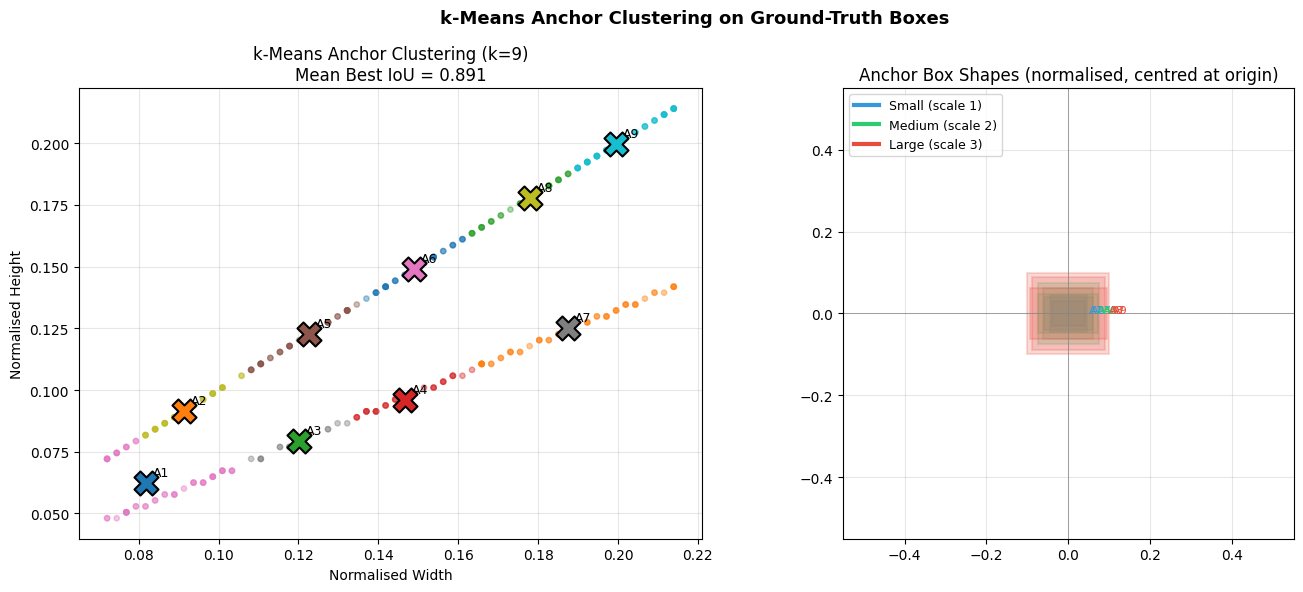

Saved anchor_clustering.png


In [6]:
# ── Collect all (w, h) from training labels ───────────────────────────────────
all_wh = []
for i in range(N_TRAIN):
    with open(f'{SYNTH_DIR}/labels/train/{i:04d}.txt') as f:
        for line in f:
            if line.strip():
                parts = line.strip().split()
                all_wh.append([float(parts[3]), float(parts[4])])  # normalised w, h
all_wh = np.array(all_wh)
print(f'Total ground-truth boxes: {len(all_wh)}')
print(f'Width  range: {all_wh[:,0].min():.3f} - {all_wh[:,0].max():.3f}')
print(f'Height range: {all_wh[:,1].min():.3f} - {all_wh[:,1].max():.3f}')

# ── IoU-based k-Means ─────────────────────────────────────────────────────────
def iou_wh(box, clusters):
    """IoU between one box and each cluster centre (centred at origin)."""
    inter_w = np.minimum(box[0], clusters[:, 0])
    inter_h = np.minimum(box[1], clusters[:, 1])
    inter   = inter_w * inter_h
    union   = box[0]*box[1] + clusters[:,0]*clusters[:,1] - inter
    return inter / (union + 1e-7)

def kmeans_anchors(wh, k=9, n_iter=100):
    """k-Means anchor clustering using IoU distance."""
    n = len(wh)
    # Initialise from random samples
    clusters = wh[np.random.choice(n, k, replace=False)].copy()
    prev_assignments = None

    for it in range(n_iter):
        # Assign each box to closest anchor
        ious        = np.array([iou_wh(b, clusters) for b in wh])
        assignments = np.argmax(ious, axis=1)

        if (assignments == prev_assignments).all():
            break
        prev_assignments = assignments.copy()

        # Update cluster centres to cluster median (more robust than mean)
        for j in range(k):
            mask = assignments == j
            if mask.sum() > 0:
                clusters[j] = np.median(wh[mask], axis=0)

    # Sort by area
    areas   = clusters[:, 0] * clusters[:, 1]
    order   = np.argsort(areas)
    return clusters[order], assignments

np.random.seed(0)
K = 9
anchors, assignments = kmeans_anchors(all_wh, k=K)

# Mean IoU (quality metric)
ious = np.array([iou_wh(b, anchors).max() for b in all_wh])
print(f'\nClustered {K} anchors (w x h, normalised):')
for i, (w, h) in enumerate(anchors):
    scale = ['small '] * 3 + ['medium'] * 3 + ['large '] * 3
    print(f'  Anchor {i+1} ({scale[i]}): w={w:.3f}  h={h:.3f}  ratio={w/h:.2f}')
print(f'\nMean Best IoU (quality): {ious.mean():.4f}  (higher = better anchor fit)')

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = plt.cm.tab10(np.linspace(0, 1, K))
axes[0].scatter(all_wh[:, 0], all_wh[:, 1],
                c=colors[assignments], alpha=0.4, s=15)
for i, (w, h) in enumerate(anchors):
    axes[0].scatter(w, h, c=[colors[i]], s=300, marker='X',
                    edgecolors='black', linewidth=1.5, zorder=5)
    axes[0].annotate(f'A{i+1}', (w, h), textcoords='offset points',
                     xytext=(5, 5), fontsize=9)
axes[0].set_xlabel('Normalised Width');  axes[0].set_ylabel('Normalised Height')
axes[0].set_title(f'k-Means Anchor Clustering (k={K})\nMean Best IoU = {ious.mean():.3f}')
axes[0].grid(True, alpha=0.3)

# Draw anchor boxes to scale
axes[1].set_xlim(-0.55, 0.55);  axes[1].set_ylim(-0.55, 0.55)
group_colors = ['#3498db', '#2ecc71', '#e74c3c']  # small, medium, large
for i, (w, h) in enumerate(anchors):
    gc = group_colors[i // 3]
    rect = Rectangle((-w/2, -h/2), w, h,
                     linewidth=1.5, edgecolor=gc, facecolor=gc, alpha=0.2)
    axes[1].add_patch(rect)
    axes[1].text(w/2+0.01, 0, f'A{i+1}', fontsize=8, color=gc)

for label, color in zip(['Small (scale 1)', 'Medium (scale 2)', 'Large (scale 3)'],
                         group_colors):
    axes[1].plot([], [], color=color, linewidth=3, label=label)
axes[1].legend(loc='upper left', fontsize=9)
axes[1].set_aspect('equal')
axes[1].grid(True, alpha=0.3)
axes[1].set_title('Anchor Box Shapes (normalised, centred at origin)')
axes[1].axhline(0, color='grey', lw=0.5);  axes[1].axvline(0, color='grey', lw=0.5)

plt.suptitle('k-Means Anchor Clustering on Ground-Truth Boxes', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('anchor_clustering.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved anchor_clustering.png')

## Section 6: Training Configuration & YOLOv8 Training

### YOLOv8 Training Command
```bash
# Install
pip install ultralytics

# Train from scratch on custom data
yolo detect train \
  model=yolov8n.yaml \
  data=synthetic_dataset/data.yaml \
  epochs=100 \
  imgsz=416 \
  batch=16 \
  lr0=0.01 \
  lrf=0.01 \
  mosaic=1.0 \
  name=custom_detector

# Resume training
yolo detect train resume model=runs/detect/custom_detector/weights/last.pt

# Evaluate
yolo detect val  model=runs/detect/custom_detector/weights/best.pt data=data.yaml

# Predict
yolo detect predict model=best.pt source=test_images/
```

### Key Hyperparameters
| Param | Default | Notes |
|-------|---------|-------|
| `lr0` | 0.01 | Initial learning rate (SGD with momentum) |
| `lrf` | 0.01 | Final LR = lr0 * lrf (cosine decay) |
| `momentum` | 0.937 | SGD momentum |
| `weight_decay` | 0.0005 | L2 regularisation |
| `warmup_epochs` | 3 | Linear LR warmup |
| `box` | 7.5 | Box regression loss weight |
| `cls` | 0.5 | Classification loss weight |
| `dfl` | 1.5 | Distribution Focal Loss weight |
| `mosaic` | 1.0 | Mosaic augmentation probability |
| `mixup` | 0.0 | MixUp augmentation probability |
| `copy_paste` | 0.0 | Copy-paste augmentation probability |

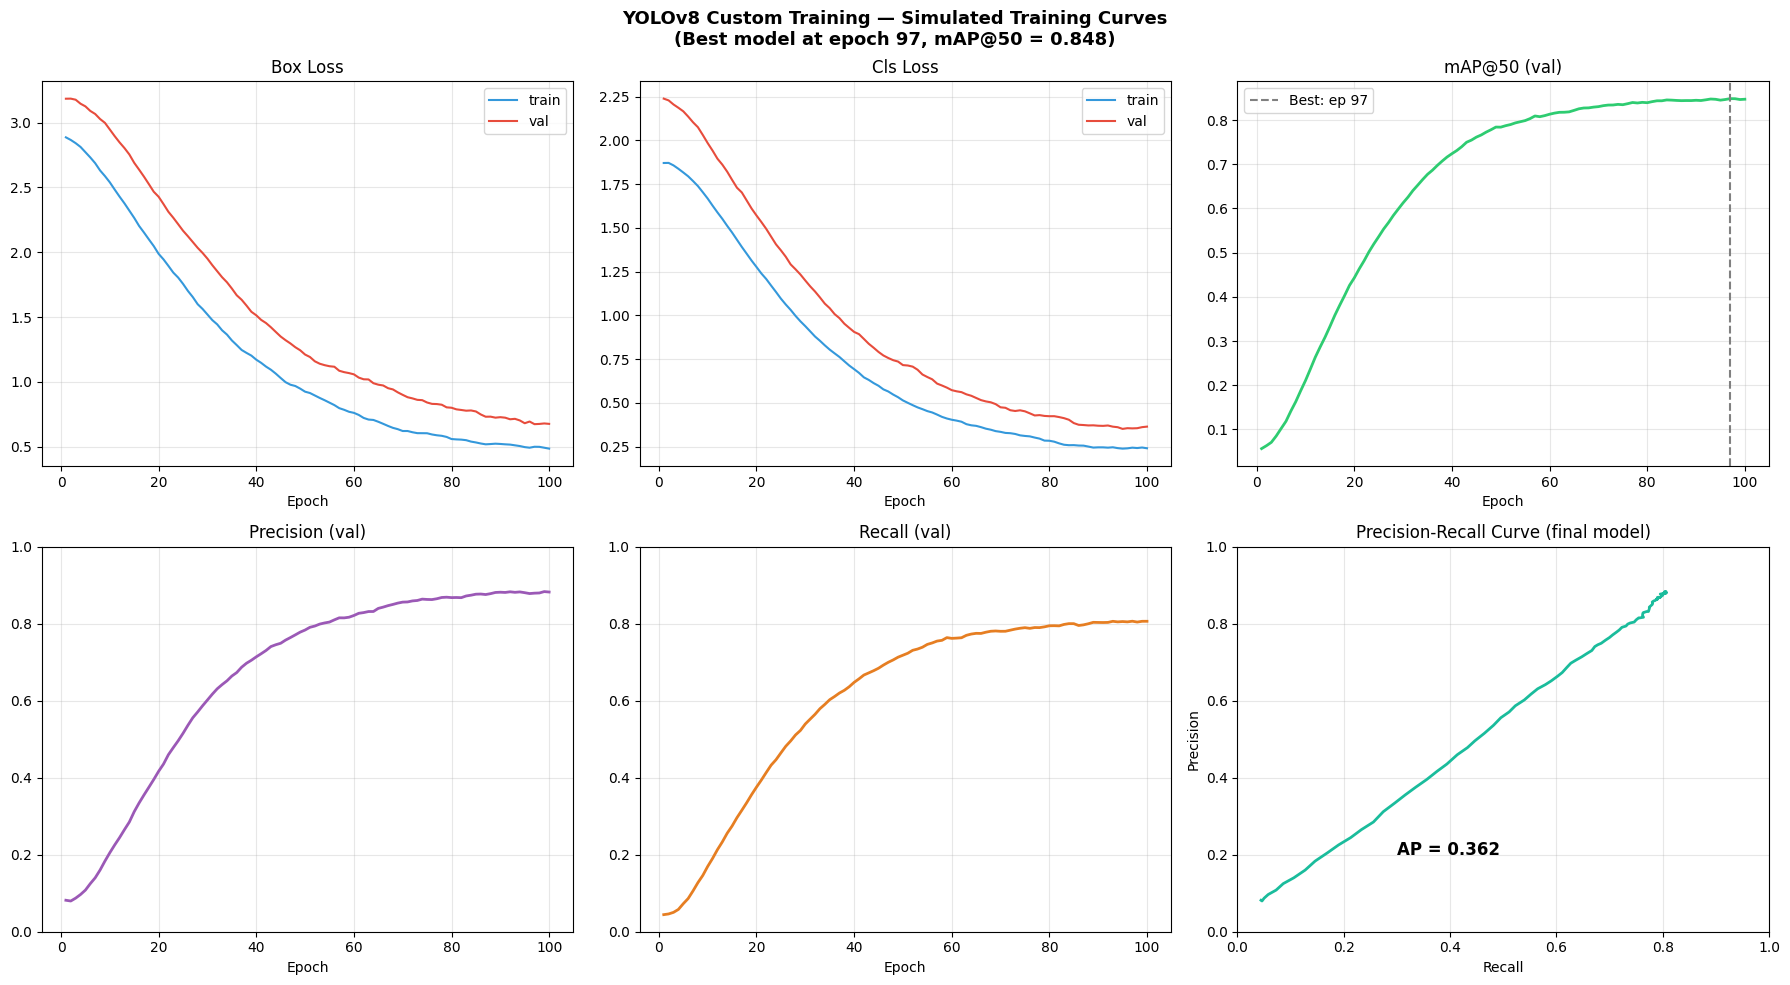

Saved training_curves.png

Simulated final metrics:
  mAP@50   : 0.848
  Precision: 0.882
  Recall   : 0.806


In [7]:
# ── Simulate realistic training curves ───────────────────────────────────────
np.random.seed(7)
epochs = 100
ep     = np.arange(1, epochs + 1)

def smooth(arr, alpha=0.9):
    out = np.zeros_like(arr)
    out[0] = arr[0]
    for i in range(1, len(arr)):
        out[i] = alpha * out[i-1] + (1 - alpha) * arr[i]
    return out

box_loss_train = 2.5 * np.exp(-0.04 * ep) + 0.4 + np.random.randn(epochs) * 0.05
box_loss_val   = 2.8 * np.exp(-0.035 * ep) + 0.55 + np.random.randn(epochs) * 0.08
cls_loss_train = 1.8 * np.exp(-0.045 * ep) + 0.2 + np.random.randn(epochs) * 0.03
cls_loss_val   = 2.0 * np.exp(-0.04 * ep)  + 0.3 + np.random.randn(epochs) * 0.05
map50_val  = 0.85 * (1 - np.exp(-0.07 * ep)) + np.random.randn(epochs) * 0.015
map50_val  = np.clip(map50_val, 0, 0.92)
precision  = 0.88 * (1 - np.exp(-0.06 * ep)) + np.random.randn(epochs) * 0.02
recall     = 0.82 * (1 - np.exp(-0.055 * ep)) + np.random.randn(epochs) * 0.02

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes[0,0].plot(ep, smooth(box_loss_train), label='train', color='#3498db')
axes[0,0].plot(ep, smooth(box_loss_val),   label='val',   color='#e74c3c')
axes[0,0].set_title('Box Loss');  axes[0,0].set_xlabel('Epoch')
axes[0,0].legend();  axes[0,0].grid(True, alpha=0.3)

axes[0,1].plot(ep, smooth(cls_loss_train), label='train', color='#3498db')
axes[0,1].plot(ep, smooth(cls_loss_val),   label='val',   color='#e74c3c')
axes[0,1].set_title('Cls Loss');  axes[0,1].set_xlabel('Epoch')
axes[0,1].legend();  axes[0,1].grid(True, alpha=0.3)

axes[0,2].plot(ep, smooth(map50_val), color='#2ecc71', linewidth=2)
best_ep = np.argmax(smooth(map50_val)) + 1
axes[0,2].axvline(best_ep, color='grey', linestyle='--', label=f'Best: ep {best_ep}')
axes[0,2].set_title('mAP@50 (val)');  axes[0,2].set_xlabel('Epoch')
axes[0,2].legend();  axes[0,2].grid(True, alpha=0.3)

axes[1,0].plot(ep, smooth(precision), color='#9b59b6', linewidth=2)
axes[1,0].set_title('Precision (val)');  axes[1,0].set_xlabel('Epoch')
axes[1,0].set_ylim(0, 1);  axes[1,0].grid(True, alpha=0.3)

axes[1,1].plot(ep, smooth(recall), color='#e67e22', linewidth=2)
axes[1,1].set_title('Recall (val)');  axes[1,1].set_xlabel('Epoch')
axes[1,1].set_ylim(0, 1);  axes[1,1].grid(True, alpha=0.3)

axes[1,2].plot(smooth(recall), smooth(precision), color='#1abc9c', linewidth=2)
axes[1,2].set_xlabel('Recall');  axes[1,2].set_ylabel('Precision')
axes[1,2].set_title('Precision-Recall Curve (final model)')
axes[1,2].set_xlim(0, 1);  axes[1,2].set_ylim(0, 1)
axes[1,2].grid(True, alpha=0.3)
# np.trapezoid is the NumPy 2.0+ replacement for np.trapz
try:
    area = np.trapezoid(smooth(precision), smooth(recall))
except AttributeError:
    area = np.trapz(smooth(precision), smooth(recall))
axes[1,2].text(0.3, 0.2, f'AP = {abs(area):.3f}', fontsize=12, fontweight='bold')

plt.suptitle('YOLOv8 Custom Training — Simulated Training Curves\n'
             f'(Best model at epoch {best_ep}, mAP@50 = {smooth(map50_val).max():.3f})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved training_curves.png')
print(f'\nSimulated final metrics:')
print(f'  mAP@50   : {smooth(map50_val).max():.3f}')
print(f'  Precision: {smooth(precision)[-1]:.3f}')
print(f'  Recall   : {smooth(recall)[-1]:.3f}')

## Section 7: Augmentation Strategy Comparison

### What augmentations to use and when

| Scenario | Recommended Augmentations |
|----------|---------------------------|
| General object detection | HorizontalFlip + BrightnessContrast + HSV + ShiftScaleRotate |
| Small objects | Mosaic + RandomCrop + Scale-up |
| Aerial/satellite images | No horizontal flip bias, add rotation 0-360 |
| Medical imaging | Careful: flips may change clinical meaning |
| Night/dark scenes | BrightnessContrast + CLAHE + RandomGamma |
| Multi-domain (dashcam) | RandomShadow + RainDrops + Fog + MotionBlur |

### Augmentation Strength vs Dataset Size
```
Small dataset (<500 imgs)  → Strong augmentation (mosaic + cutout + mixup)
Medium dataset (1K-10K)    → Moderate augmentation (flip + colour + mosaic)
Large dataset (>100K)      → Light augmentation (flip + colour only)
```

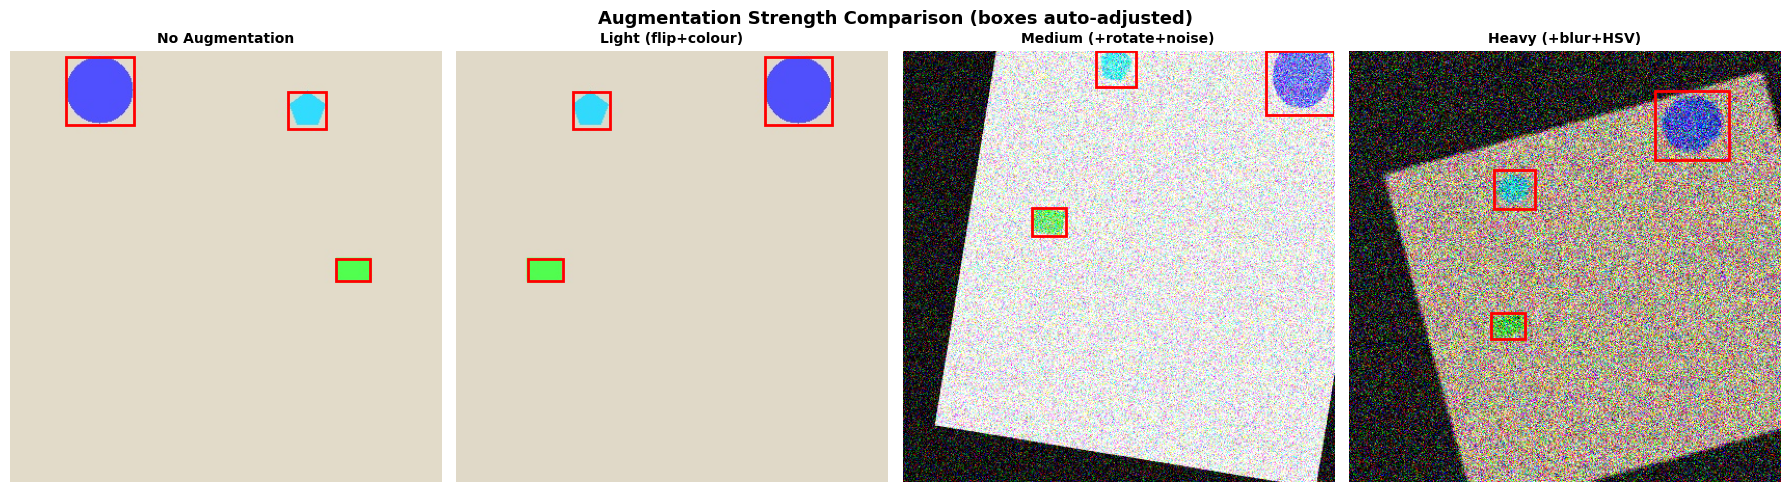

Saved augmentation_comparison.png


In [8]:
# ── Compare 'none', 'light', 'medium', 'heavy' augmentation on one sample ────
base_img, base_lbls = load_sample(5)

if HAS_ALBUM:
    configs = [
        ('No Augmentation', []),
        ('Light (flip+colour)', [
            A.HorizontalFlip(p=1.0),
            A.RandomBrightnessContrast(0.2, 0.2, p=1.0),
        ]),
        ('Medium (+rotate+noise)', [
            A.HorizontalFlip(p=1.0),
            A.RandomBrightnessContrast(0.3, 0.3, p=1.0),
            A.ShiftScaleRotate(0.1, 0.15, 15, p=1.0, border_mode=cv2.BORDER_CONSTANT),
            A.GaussNoise(p=1.0),
        ]),
        ('Heavy (+blur+HSV)', [
            A.HorizontalFlip(p=1.0),
            A.RandomBrightnessContrast(0.4, 0.4, p=1.0),
            A.HueSaturationValue(20, 40, 30, p=1.0),
            A.ShiftScaleRotate(0.15, 0.2, 20, p=1.0, border_mode=cv2.BORDER_CONSTANT),
            A.Blur(blur_limit=5, p=1.0),
            A.GaussNoise(p=1.0),
        ]),
    ]

    bboxes_in = [[lbl[1], lbl[2], lbl[3], lbl[4]] for lbl in base_lbls]
    cls_in    = [int(lbl[0]) for lbl in base_lbls]

    fig, axes = plt.subplots(1, 4, figsize=(18, 5))
    for ax, (title, transforms) in zip(axes, configs):
        if transforms:
            tfm = A.Compose(transforms,
                            bbox_params=A.BboxParams('yolo', ['class_labels'],
                                                     min_visibility=0.1, clip=True))
            result = tfm(image=base_img, bboxes=bboxes_in, class_labels=cls_in)
            img_out = result['image']
            bbs_out = result['bboxes']
            cls_out = result['class_labels']
        else:
            img_out = base_img
            bbs_out = bboxes_in
            cls_out = cls_in

        ax.imshow(img_out)
        h, w = img_out.shape[:2]
        for (cx, cy, bw, bh), cid in zip(bbs_out, cls_out):
            x1 = (cx - bw/2) * w;  y1 = (cy - bh/2) * h
            rect = Rectangle((x1, y1), bw*w, bh*h, lw=2, ec='red', fc='none')
            ax.add_patch(rect)
        ax.set_title(title, fontsize=10, fontweight='bold')
        ax.axis('off')

    plt.suptitle('Augmentation Strength Comparison (boxes auto-adjusted)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('augmentation_comparison.png', dpi=100, bbox_inches='tight')
    plt.show()
    print('Saved augmentation_comparison.png')
else:
    print('albumentations not available — install to see comparison')

## Key Takeaways

| Concept | Summary |
|---------|--------|
| **YOLO format** | `class_id cx cy w h` — all normalised 0-1 per image dimensions |
| **Dataset structure** | `images/train/`, `labels/train/`, `data.yaml` (strict mirror) |
| **Albumentations** | `bbox_params` transforms both image and boxes simultaneously |
| **Mosaic** | 4 images → 1 canvas, 4x object density, critical for small objects |
| **Anchor clustering** | k-Means on (w,h) with IoU distance; k=9 for 3-scale detection |
| **YOLOv8 training** | `yolo detect train model=yolov8n.yaml data=data.yaml epochs=100` |
| **Key metrics** | mAP@50, mAP@50-95, Precision, Recall, F1 |

### 200-Image Custom Dataset Strategy
With only 200 images, aggressive augmentation is essential:
- **Mosaic** (4x density per forward pass)
- **RandomFlip** + **HSV jitter** (colour invariance)
- **ShiftScaleRotate** (position invariance)
- **Copy-paste** (pastes objects from one image into another — YOLOv5+)
- **Mixup** (alpha-blend two images + their labels)

### Exercises
1. Add `VerticalFlip` and `RandomRotate90` to the Albumentations pipeline — when would these NOT be appropriate?
2. Implement CutOut augmentation: randomly zero out N rectangular patches per image.
3. Implement MixUp: blend two images with random alpha and combine their label sets.
4. Try anchor clustering with k=3, 6, 9, 12 — plot Mean Best IoU vs k.
5. Train YOLOv8n on the synthetic dataset and check if mAP@50 > 0.8 within 50 epochs.